# TensorFlow Autoencoder simple example
- from [Intro to Autoencoders](https://www.tensorflow.org/tutorials/generative/autoencoder)

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score


/Users/ricky/VSCODE/timeseries_autoencoder/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
import sys
import os

sys.path.append(os.path.join('..','src'))
from mlx_timeseries_workbench.utils import plot_reconstruction
from mlx_timeseries_workbench.data import get_tensorflow_ECG5000
from mlx_timeseries_workbench.tf_models.autoencoders import FixedLengthFullyConnectedAutoEncoder

## Data download

In [4]:
train_data, test_data, train_labels, test_labels = get_tensorflow_ECG5000()

## Data normalization

In [5]:
min_val = np.min(train_data)
max_val = np.max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = np.float32(train_data)
test_data = np.float32(test_data)

## Nominal / Anomalous data separation

In [6]:
normal_train_data = train_data[train_labels == 0]
anomalous_train_data = train_data[train_labels == 1]

len(normal_train_data), len(anomalous_train_data)

(2359, 1639)

### Plot a normal vs anomalous ECG

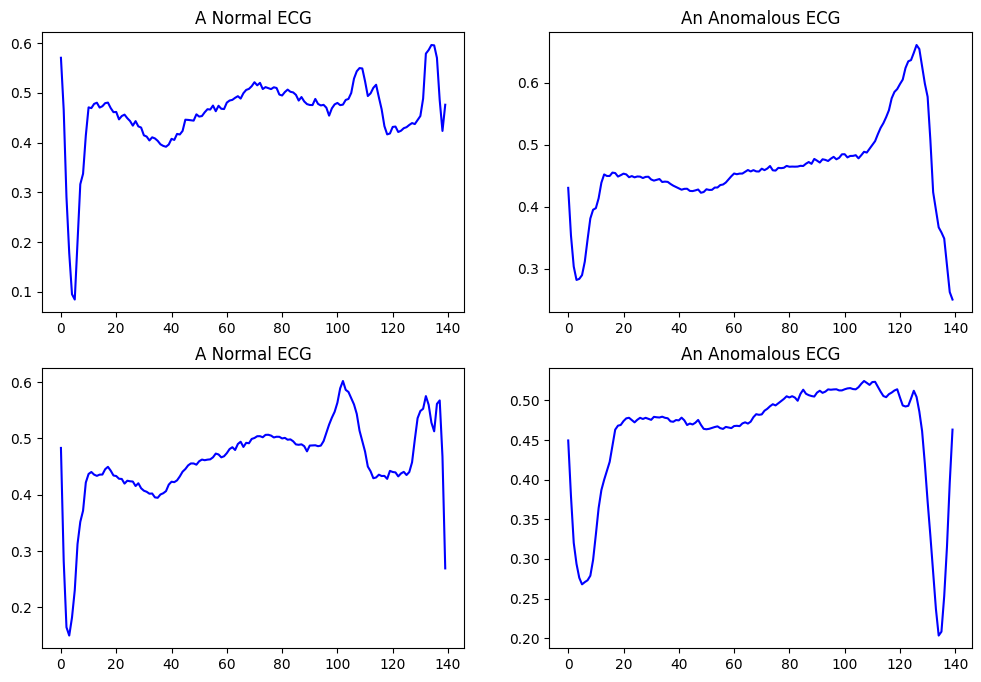

In [7]:
samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):
    plot_reconstruction(normal_train_data[s], axes[s][0]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_train_data[s], axes[s][1]).set_title("An Anomalous ECG")


In [8]:
# split train set to get a validation
validation_fraction = 0.02

rng = np.random.default_rng(123)
index = np.arange(len(normal_train_data))

t = int(validation_fraction * len(normal_train_data))

validation_set = normal_train_data[:t]
train_set = normal_train_data[t:]

assert len(normal_train_data) == len(train_set) + len(validation_set)
print(f'train size: {len(train_set)} - validation size: {len(validation_set)}')

train size: 2312 - validation size: 47


In [9]:
autoencoder = FixedLengthFullyConnectedAutoEncoder()
autoencoder.compile(optimizer='adam', loss='mae')

history = autoencoder.fit(
    train_set,
    train_set,
    epochs=400,
    batch_size=256,
    validation_data=(validation_set, validation_set),
    shuffle=True
)

Epoch 1/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0583 - val_loss: 0.0562
Epoch 2/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0547 - val_loss: 0.0522
Epoch 3/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0496 - val_loss: 0.0451
Epoch 4/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0422 - val_loss: 0.0374
Epoch 5/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0355 - val_loss: 0.0320
Epoch 6/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0312 - val_loss: 0.0286
Epoch 7/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0283 - val_loss: 0.0263
Epoch 8/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0265 - val_loss: 0.0249
Epoch 9/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0252 - val_loss: 0.0237
Epoch 10/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0241 - val_loss: 0.0227
Epoch 11/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0231 - val_loss: 0.0217
Epoch 12/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

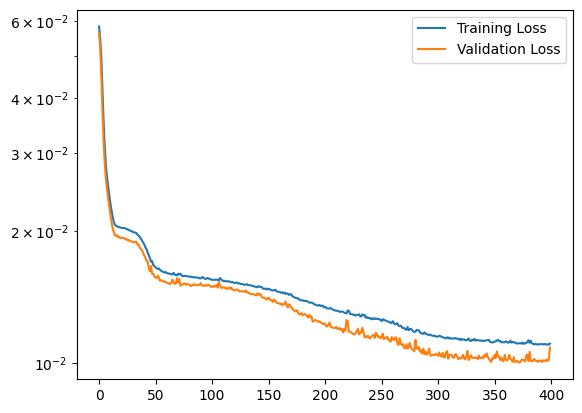

In [10]:
plt.semilogy(history.history["loss"], label="Training Loss")
plt.semilogy(history.history["val_loss"], label="Validation Loss")
plt.legend()

## Evaluate recontructions on Test data

In [11]:
normal_test_data = test_data[test_labels == 0]
anomalous_test_data = test_data[test_labels == 1]

normal_test_encoded = autoencoder.encoder(normal_test_data).numpy()
normal_test_reconstructed = autoencoder.decoder(normal_test_encoded).numpy()

anomalous_test_encoded = autoencoder.encoder(anomalous_test_data).numpy()
anomalous_test_reconstructed = autoencoder.decoder(anomalous_test_encoded).numpy()

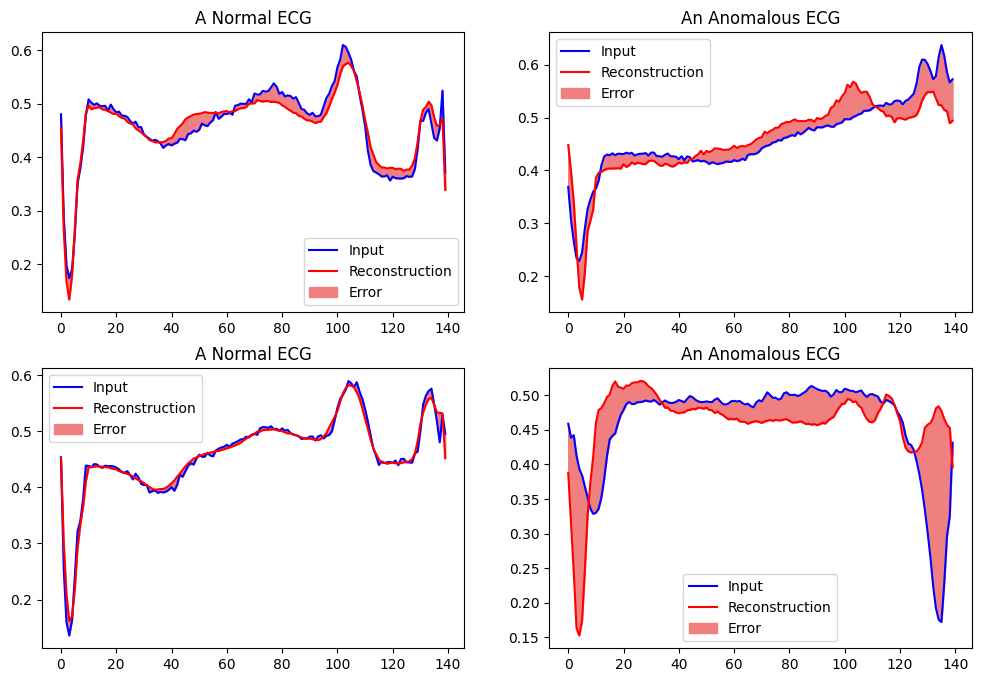

In [12]:

samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):

    plot_reconstruction(normal_test_data[s], axes[s][0], reconstruction=normal_test_reconstructed[s]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_test_data[s], axes[s][1], reconstruction=anomalous_test_reconstructed[s]).set_title("An Anomalous ECG")


## Find anomalies

In [13]:
normal_train_reconstructed = autoencoder.predict(normal_train_data)
normal_train_loss = tf.keras.losses.mae(normal_train_reconstructed, normal_train_data).numpy()

anomalous_train_reconstructed = autoencoder.predict(anomalous_train_data)
anomalous_train_loss = tf.keras.losses.mae(anomalous_train_reconstructed, anomalous_train_data).numpy()

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step


In [14]:
threshold = np.mean(normal_train_loss) + np.std(normal_train_loss)
print("Threshold: ", threshold)

Threshold:  0.016919728


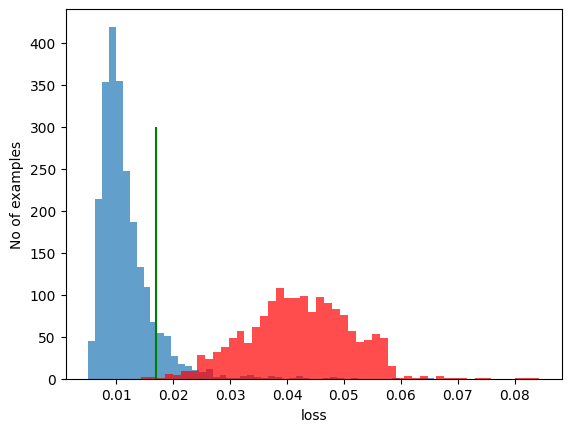

In [15]:
plt.hist(normal_train_loss, bins=50, alpha = 0.7)
plt.hist(anomalous_train_loss, bins=50, color='red', alpha=0.7)
plt.xlabel("loss")
plt.ylabel("No of examples")
plt.vlines([threshold], 0, 300, colors=['green'])

In [16]:
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.greater(loss, threshold)

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

In [17]:
preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.94
Precision = 0.8846153846153846
Recall = 0.9931818181818182


In [18]:
df = pd.DataFrame(
    data = {
        'ground_truth': test_labels,
        'predicted': preds
    }
)

df

,ground_truth,predicted
0,0,False
1,1,True
2,0,False
3,0,True
4,1,True
...,...,...
995,1,True
996,0,False
997,0,True
998,0,False


In [19]:
errors = df[df['ground_truth'] !=  df['predicted']]
corrects = df[df['ground_truth'] ==  df['predicted']]

In [20]:
# it seems that I need to find Flse for positives and True for negatives
false_positives = errors[errors['predicted'] == True]
false_negatives = errors[errors['predicted'] == False]

true_positives = corrects[corrects['ground_truth'] == True]
true_negatives = corrects[corrects['ground_truth'] == False]

In [21]:
n_true_positives = len(true_positives)
n_true_negatives = len(true_negatives)
n_false_positives = len(false_positives)
n_false_negatives = len(false_negatives)

print(f'accuracy: {(n_true_positives + n_true_negatives) / (n_true_positives + n_true_negatives + n_false_positives + n_false_negatives)}')
print(f'precision: {(n_true_positives) / (n_true_positives + n_false_positives)}')
print(f'recall: {(n_true_positives) / (n_true_positives + n_false_negatives)}')

accuracy: 0.94
precision: 0.8846153846153846
recall: 0.9931818181818182


## Examining false positives

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Threshold:  0.016919728
false_positives_loss:  [0.01774569 0.04292179 0.02246727 0.01922509 0.01861909 0.01709959
 0.01723968 0.01857669 0.017931   0.03564787 0.01917737 0.0194598
 0.0174643  0.0182703  0.01753305 0.02099597 0.01818958 0.02293939
 0.01821823 0.02051549 0.01729983 0.02699764 0.02161077 0.01740631
 0.01925871 0.01820081 0.03813126 0.02329836 0.02330341 0.01814004
 0.02004165 0.01735031 0.01781056 0.02129856 0.02246117 0.02039053
 0.02031245 0.02382143 0.0205746  0.02091608 0.01833147 0.020913
 0.0288697  0.0311624  0.01895361 0.02030325 0.01840062 0.01788078
 0.01920782 0.01869685 0.01771819 0.02696226 0.01990306 0.01985906
 0.02147105 0.02639083 0.0211573 ]


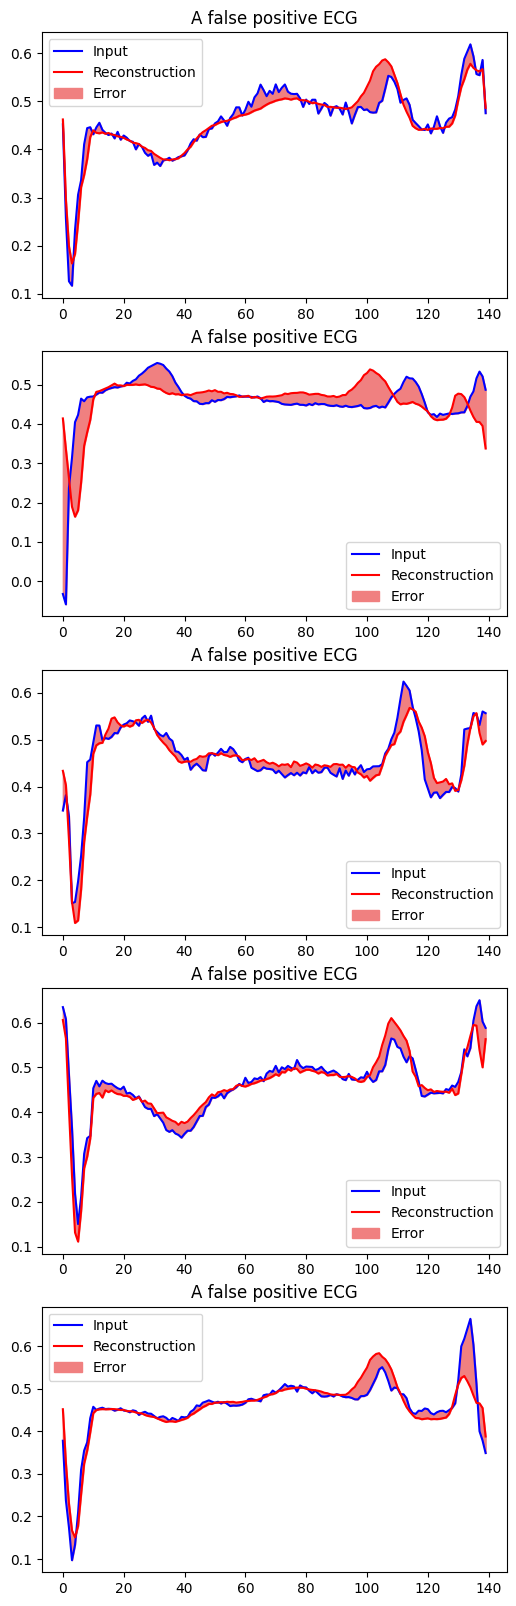

In [22]:
fp_idx = false_positives.index.values


if fp_idx.size > 0:
    false_positives_data = test_data[fp_idx]
    false_positives_reconstructed = autoencoder.predict(false_positives_data)
    false_positives_loss = tf.keras.losses.mae(false_positives_reconstructed, false_positives_data).numpy()
    
    print("Threshold: ", threshold)
    print("false_positives_loss: ", false_positives_loss)
    
    samples = np.min([5, len(fp_idx)])
    fig, axes = plt.subplots(samples, 1, figsize=(6,4*samples), squeeze = False)
    
    for s in range(samples):
        plot_reconstruction(false_positives_data[s], axes[s][0], reconstruction=false_positives_reconstructed[s]).set_title("A false positive ECG")


## Examining false negatives

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Threshold:  0.016919728
false_negatives_loss:  [0.01675674 0.00849833 0.00906803]


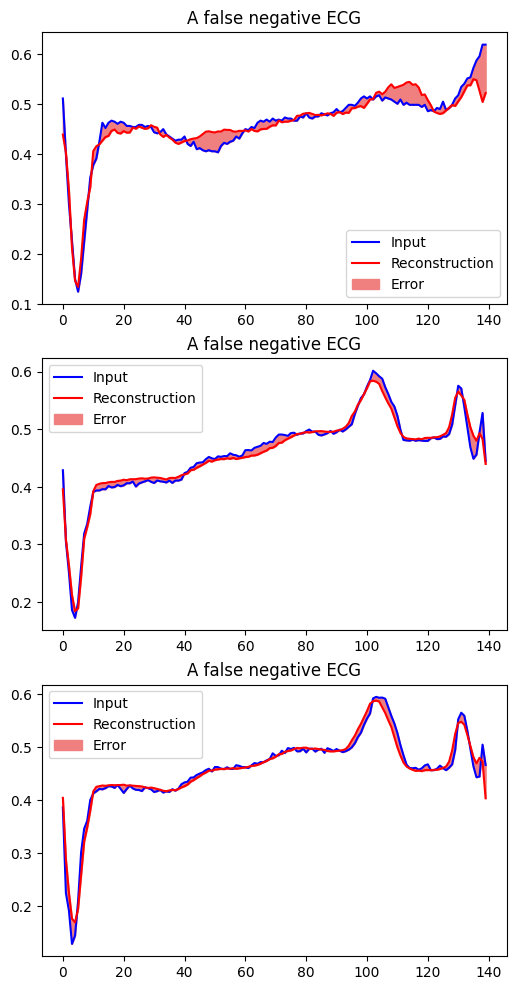

In [23]:
fn_idx = false_negatives.index.values

if fn_idx.size > 0:
    false_negatives_data = test_data[fn_idx]
    false_negatives_reconstructed = autoencoder.predict(false_negatives_data)
    false_negatives_loss = tf.keras.losses.mae(false_negatives_reconstructed, false_negatives_data).numpy()

    print("Threshold: ", threshold)
    print("false_negatives_loss: ", false_negatives_loss)

    samples = np.min([5, len(fn_idx)])
    fig, axes = plt.subplots(samples, 1, figsize=(6,4*samples), squeeze = False)

    for s in range(samples):
        plot_reconstruction(false_negatives_data[s], axes[s][0], reconstruction=false_negatives_reconstructed[s]).set_title("A false negative ECG")
